#Customer Segmentationn for Telecom Users

Project Title

Customer Segmentationn for Telecom Users

Leader in Consulting

https://gncipl.com/

GNCIPL.jpg

GitHub Repository

https://github.com/simranbhadouria/Customer-Segmentation-for-Telecom-Users-Using-Machine-Learning-project-9

Dataset

https://www.kaggle.com/datasets/teamincribo/cyber-security-attacks

Objective

Segment telecom customers based on usage behavior, tenure, billing, and payment methods.


Algorithm Used:

K-Means Clustering
StandardScaler
Label Encoding


EDA Performed:

Churn Analysis
Contract Analysis
Phone Service Analysis
Payment Method Analysis
Monthly Charges Distribution
Total Charges Distribution
Tenure Distribution
Correlation Heatmap

Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

Read CSV

In [ ]:
df = pd.read_csv('/content/churn_data.csv')

df.head()

,customerID,tenure,PhoneService,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,1,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,34,Yes,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,2,Yes,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,45,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,2,Yes,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
print(df.shape)

(7043, 14)


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   tenure            7043 non-null   int64  
 2   PhoneService      7043 non-null   object 
 3   Contract          7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   object 
 8   Churn             7043 non-null   object 
dtypes: float64(1), int64(1), object(7)
memory usage: 495.3+ KB
None


In [ ]:
print(df.describe())

            tenure  MonthlyCharges
count  7043.000000     7043.000000
mean     32.371149       64.761692
std      24.559481       30.090047
min       0.000000       18.250000
25%       9.000000       35.500000
50%      29.000000       70.350000
75%      55.000000       89.850000
max      72.000000      118.750000


Handle Missing Values

In [ ]:
df.drop("customerID", axis=1, inplace=True)

In [ ]:
print(df.columns)

Index(['customerID', 'tenure', 'PhoneService', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


Convert TotalCharges to Numeric

In [ ]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"],errors="coerce")

Check Missing Values

In [ ]:
df.isnull().sum()

,0
tenure,0
PhoneService,0
Contract,0
PaperlessBilling,0
PaymentMethod,0
MonthlyCharges,0
TotalCharges,11
Churn,0
SeniorCitizen,0
Partner,0


Fill Missing Values

In [ ]:
df["TotalCharges"].fillna(df["TotalCharges"].median(),inplace=True)

/tmp/ipykernel_5802/1795292956.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(df["TotalCharges"].median(),inplace=True)


EDA (Exploratory Data Analysis)

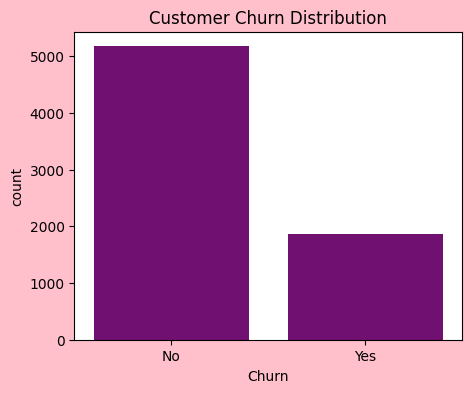

In [ ]:
#Churn Distribution
plt.figure(figsize=(5,4),facecolor = "pink")
sns.countplot(x="Churn",data=df,color="purple")
plt.title("Customer Churn Distribution")
plt.show()

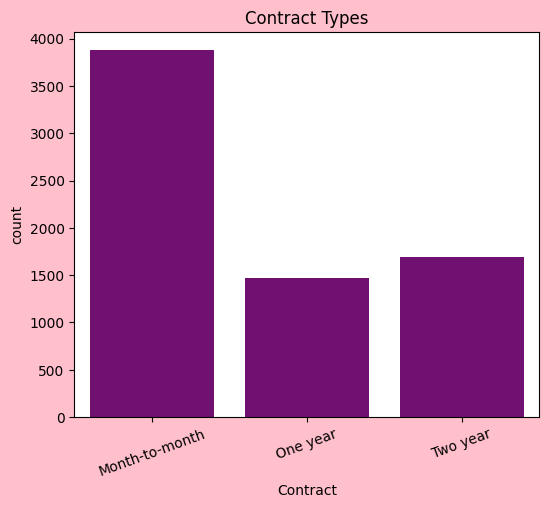

In [ ]:
#Contract Type Distribution
plt.figure(figsize=(6,5),facecolor = "pink")
sns.countplot(x="Contract",data=df,color="purple")

plt.title("Contract Types")
plt.xticks(rotation=20)
plt.show()

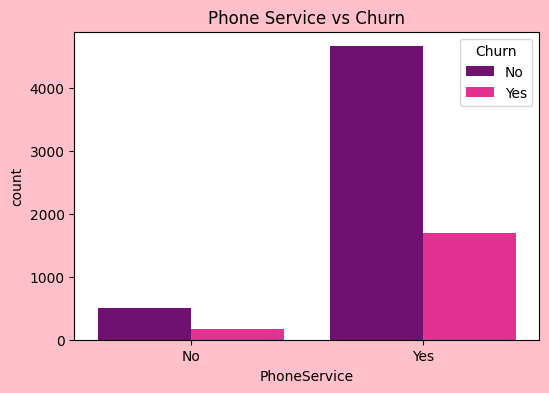

In [ ]:
#Phone Service Analysis
plt.figure(figsize=(6,4),facecolor = "pink")

sns.countplot(x="PhoneService",hue="Churn",data=df,palette=['purple', 'deeppink'])

plt.title("Phone Service vs Churn")
plt.show()

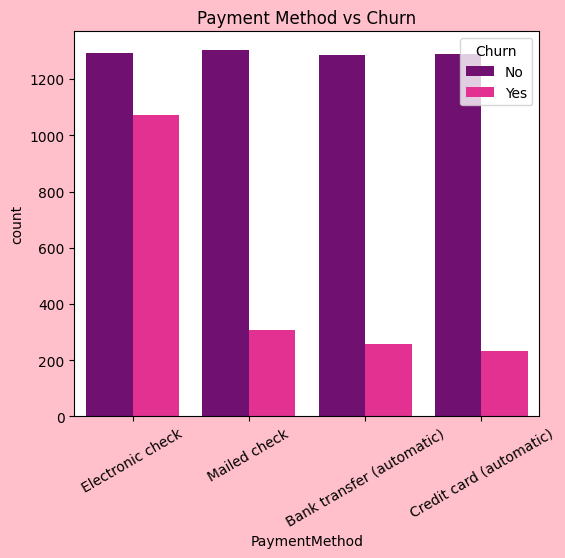

In [ ]:
#Payment Method Analysis
plt.figure(figsize=(6,5),facecolor = "pink")

sns.countplot(x="PaymentMethod",hue="Churn",data=df,palette=['purple', 'deeppink'])
plt.xticks(rotation=30)
plt.title("Payment Method vs Churn")
plt.show()

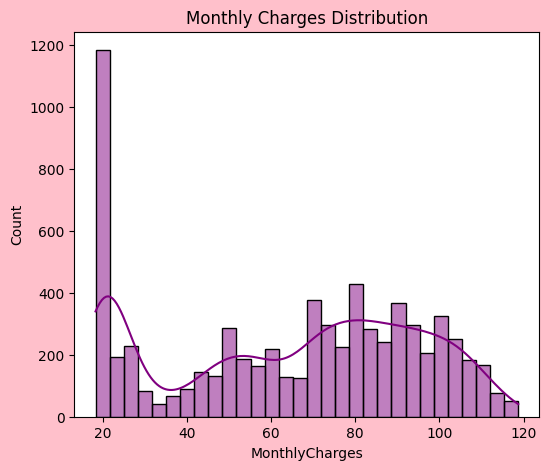

In [ ]:
#Monthly Charges Distribution
plt.figure(figsize=(6,5), facecolor = "pink")

sns.histplot(df["MonthlyCharges"],bins=30,kde=True,color= "purple")

plt.title("Monthly Charges Distribution")
plt.show()

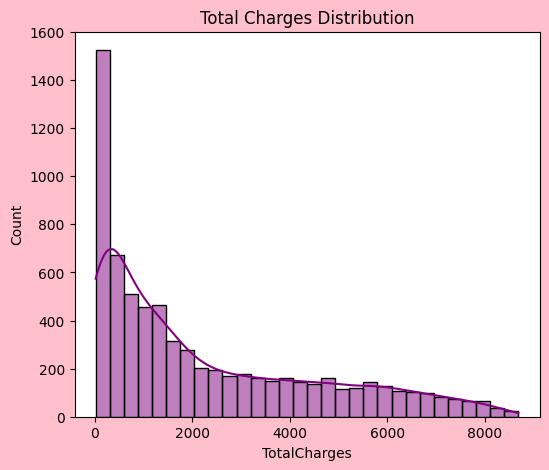

In [ ]:
#Total Charges Distribution
plt.figure(figsize=(6,5),facecolor="pink")
sns.histplot(df["TotalCharges"],bins=30,kde=True,color= "purple")
plt.title("Total Charges Distribution")
plt.show()

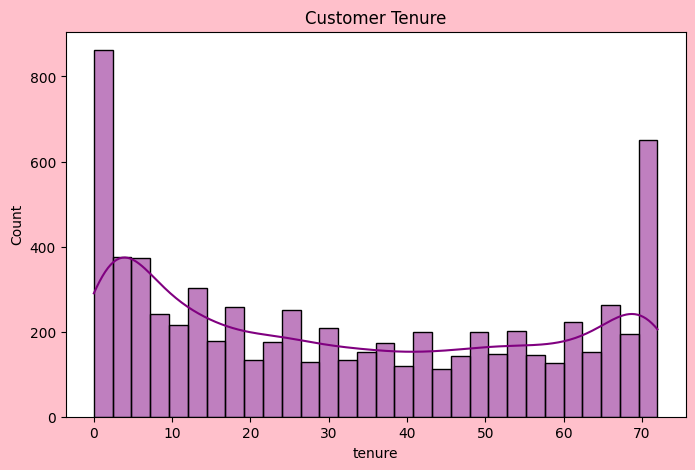

In [ ]:
#Tenure Distribution
plt.figure(figsize=(8,5),facecolor="pink")

sns.histplot(df["tenure"],bins=30,kde=True,color="purple")
plt.title("Customer Tenure")
plt.show()

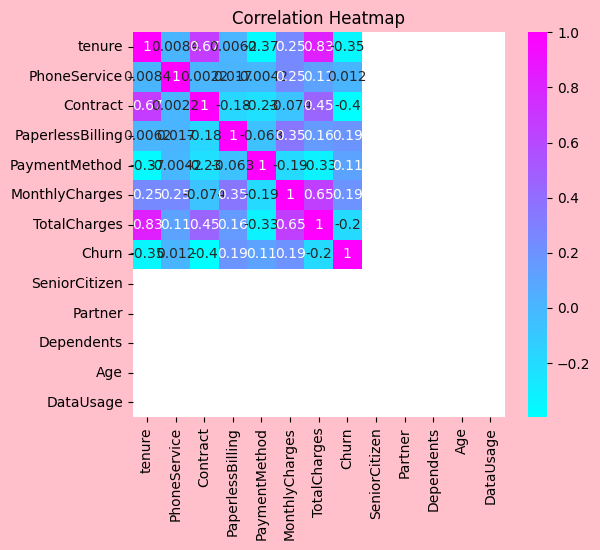

In [ ]:
#Encode categorical columns
temp_df = df.copy()
le = LabelEncoder()
for col in temp_df.select_dtypes(include="object"):temp_df[col] = le.fit_transform(temp_df[col])
#Correlation Heatmap
plt.figure(figsize=(6,5),facecolor="pink")
sns.heatmap(temp_df.corr(),annot=True,cmap="cool")
plt.title("Correlation Heatmap")
plt.show()

Feature Encoding

In [ ]:
df_ml = df.copy()
le = LabelEncoder()

for col in df_ml.select_dtypes(include="object"):
    df_ml[col] = le.fit_transform(df_ml[col])

Feature Scaling

In [ ]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_ml)

Optimal K (Elbow Method)

In [ ]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i,random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

Plot Elbow Curve

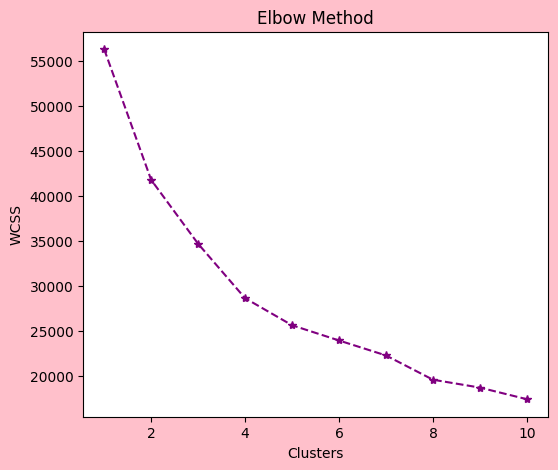

In [ ]:
plt.figure(figsize=(6,5),facecolor = "pink")

plt.plot(range(1,11),wcss,marker='*',linestyle='--',color="purple")
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

Customer Segmentation Model

In [ ]:
kmeans = KMeans(n_clusters=4,random_state=42)
clusters = kmeans.fit_predict(scaled_data)

In [ ]:
df["Cluster"] = clusters

In [ ]:
df.head()

,tenure,PhoneService,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,SeniorCitizen,Partner,Dependents,Age,DataUsage,Cluster
0,1,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0,No,No,0,0,0
1,34,Yes,One year,No,Mailed check,56.95,1889.50,No,0,No,No,0,0,3
2,2,Yes,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0,No,No,0,0,1
3,45,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0,No,No,0,0,0
4,2,Yes,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0,No,No,0,0,1


Cluster Analysis

In [ ]:
df.groupby("Cluster").mean(numeric_only=True)

,tenure,MonthlyCharges,TotalCharges,SeniorCitizen,Age,DataUsage
Cluster,,,,,,
0,31.737537,42.028592,1500.131818,0.0,0.0,0.0
1,14.630611,77.207781,1200.732108,0.0,0.0,0.0
2,59.020910,91.420125,5408.624203,0.0,0.0,0.0
3,28.078236,34.128687,897.695839,0.0,0.0,0.0


Segment Visualization

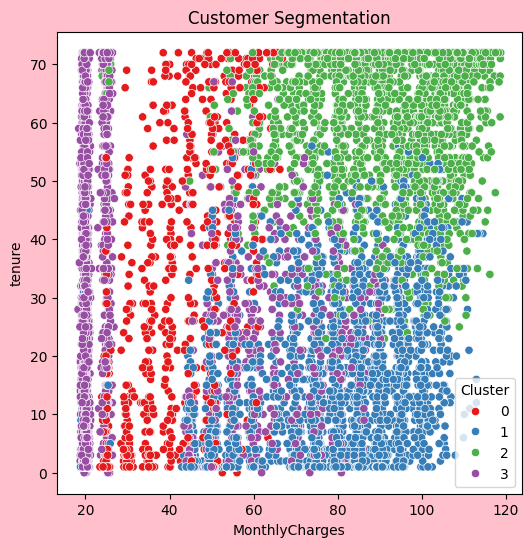

In [ ]:
#Monthly Charges vs Tenure
plt.figure(figsize=(6,6),facecolor ='pink')
sns.scatterplot(x="MonthlyCharges",y="tenure",hue="Cluster",data=df,palette="Set1")
plt.title("Customer Segmentation")
plt.show()

In [ ]:
#Silhouette Score
score = silhouette_score(scaled_data,clusters)
print("Silhouette Score:", score)

Silhouette Score: 0.2774133460545217


**Conclusion**

This project successfully implemented Customer Segmentation for Telecom Users using Machine Learning techniques. The primary objective was to analyze customer behavior and group customers into meaningful segments based on factors such as tenure, monthly charges, total charges, contract type, payment method, and service usage patterns.

During the project, extensive Exploratory Data Analysis (EDA) was performed to understand customer demographics, service preferences, billing patterns, and churn behavior. The analysis revealed significant relationships between customer tenure, contract types, monthly charges, and customer retention.

After preprocessing the data through data cleaning, encoding, and feature scaling, the K-Means Clustering algorithm was applied to identify distinct customer groups. The clustering process successfully categorized customers into different segments, such as loyal customers, high-value customers, potential churners, and newly acquired customers. These segments provide valuable insights into customer behavior and purchasing patterns.

The findings from this project can help telecom companies:

Design targeted marketing campaigns for specific customer groups.
Improve customer retention strategies by identifying high-risk customers.
Offer personalized services and promotions.
Enhance customer satisfaction and loyalty.
Optimize business decisions using data-driven insights.

Overall, the project demonstrates how Machine Learning and Data Analytics can be leveraged to transform raw customer data into actionable business intelligence. The developed customer segmentation model provides a strong foundation for future enhancements, such as churn prediction, recommendation systems, and personalized customer engagement strategies.

Future Scope
Implement advanced clustering techniques such as DBSCAN or Hierarchical Clustering.
Build a Customer Churn Prediction model using classification algorithms.
Integrate real-time customer data for dynamic segmentation.
Develop an interactive dashboard using Power BI or Tableau for business users.
Deploy the model as a web application using Flask, Streamlit, or FastAPI.

Final Outcome:
The project successfully segmented telecom customers into meaningful groups, enabling telecom service providers to better understand their customers, improve retention, increase revenue, and make informed business decisions through Machine Learning-driven insights.